In [1]:
import numpy as np
import random
import pandas as pd
from scipy.stats import norm
import torch
from torch import nn
import normflows as nf
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from scipy.interpolate import griddata
import seaborn as sns
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.gridspec as gridspec

np.random.seed(0)

I = 5
tau = 0.2783047
data_normalized = pd.read_csv('data_normalized.csv')
df_means = pd.read_csv('df_means.csv')
df_stds = pd.read_csv('df_stds.csv')

ids =  data_normalized['ID'].unique()
cols = ['logAge', 'FeH', 'parallax', 'absorption', 'mass']

# Loading Stage 1 Models

In [2]:
folder = "Forward_Models"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for id in ids:
    path = f"{folder}/stage1_{id}.pth"
    globals()[f"stage1_id{id}"] =  torch.load(path)
    globals()[f"stage1_id{id}"] = globals()[f"stage1_id{id}"].to(device).float().eval()
    for p in globals()[f"stage1_id{id}"].parameters():
        p.requires_grad_(False)


/var/folders/s6/3hm9br8d11539r6399q4fstr0000gn/T/ipykernel_91705/1895200698.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  globals()[f"stage1_id{id}"] =  torch.load(pat

# Reverse KL

100%|██████████| 30000/30000 [2:48:01<00:00,  2.98it/s]  


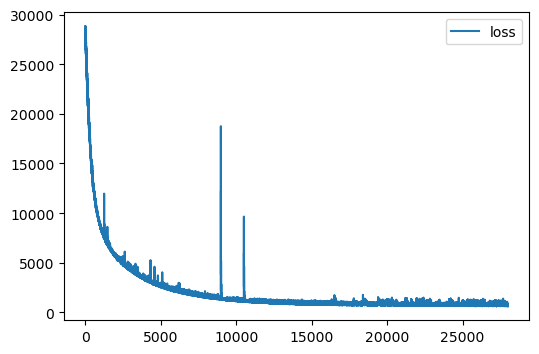

In [3]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

# -------------------------------------
# Tuning and model setup
# -------------------------------------
K = 3
m = 5
max_iter = 30000
num_samples0 = 1000
lr = 5e-5

selected_ids = ids # including all 30 stars in the NF model
n_age = len(selected_ids)
latent_size=n_age*5+1 # 5 parameters per star + gamma
age_index = [5*i for i in range(n_age)]
star_index = [list(range(i*5, (i+1)*5)) for i in range(n_age)]

# -------------------------------------
# Layer Structure
# -------------------------------------
flows = []
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
for i in range(K):
    s = nf.nets.MLP([latent_size, m * latent_size, latent_size], init_zeros=True)
    t = nf.nets.MLP([latent_size, m * latent_size, latent_size], init_zeros=True)
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.LULinearPermute(latent_size)]
flows += [nf.flows.ActNorm(latent_size)]

# -------------------------------------
# Target Distribution Definition
# -------------------------------------
class MyCustomTarget(nn.Module):
    def __init__(self,tau):
        super().__init__()
        self.tau = tau

    def log_prob(self, t):
        if torch.isnan(t).any() or torch.isinf(t).any():
            return torch.tensor(float('inf'), device=t.device, dtype=torch.float32)
        age = t[:, age_index]
        gamma_value = t[:, latent_size-1].unsqueeze(-1) 
        batch_size = t.shape[0]

        log_p_nfm = torch.zeros(batch_size, dtype=torch.float32, device=t.device)
        for i in range(n_age):
            model = globals()[f"stage1_id{selected_ids[i]}"]
            input_i = t[:, star_index[i]]
            mu = torch.as_tensor(
                df_means.loc[selected_ids[i]-1, cols].values,
                device=t.device,
                dtype=torch.float32,
            )

            sd = torch.as_tensor(
                df_stds.loc[selected_ids[i]-1, cols].values,
                device=t.device,
                dtype=torch.float32,
            ) 
            input_i = (input_i - mu)/ sd
            logp_i = model.log_prob(input_i) # Stage 1 models were fitted on standardized data
            
            logp_i[~torch.isfinite(logp_i)] = torch.tensor(-1e50, dtype=torch.float32, device=device)

            log_p_nfm += logp_i
       
        gamma_expanded = gamma_value.expand(-1, n_age) 
        log_p_theta_given_gamma = torch.distributions.Normal(loc=gamma_expanded, scale=self.tau).log_prob(age).sum(dim=-1)
        log_p_gamma = torch.distributions.Normal(9., 0.5).log_prob(gamma_value.squeeze(-1))  
        
        log_p_cbc = 0 # uniform prior
        return log_p_nfm + log_p_theta_given_gamma + log_p_gamma - log_p_cbc

# -------------------------------------
# Base Distribution and NF Model
# -------------------------------------
q0_new = nf.distributions.DiagGaussian(latent_size)
tau = torch.tensor(tau, dtype=torch.float32, device=device) 
my_target = MyCustomTarget(tau)

nfm = nf.NormalizingFlow(q0=q0_new, flows=flows, p=my_target)
nfm = nfm.to(device)
nfm = nfm.float()

# -------------------------------------
# Training
# -------------------------------------
with torch.no_grad(): # Helps stablize the Actnorm layer
    _ = nfm.sample(1000)

loss_hist = np.array([])
optimizer = torch.optim.Adam(nfm.parameters(), lr=lr, weight_decay=1e-6)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    loss = nfm.reverse_kld(num_samples = num_samples0)
    
    if torch.isnan(loss) or torch.isinf(loss):
        print(f"⚠️ NaN or Inf detected in loss at iteration {it}")
        continue 

    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
plt.figure(figsize=(6, 4))
plt.plot(loss_hist[2000:], label='loss')
plt.legend()
plt.show()


In [4]:
torch.save(nfm, "Final_Model.pth")
torch.save(nfm.state_dict(), f"Final_Model_dict.pth")

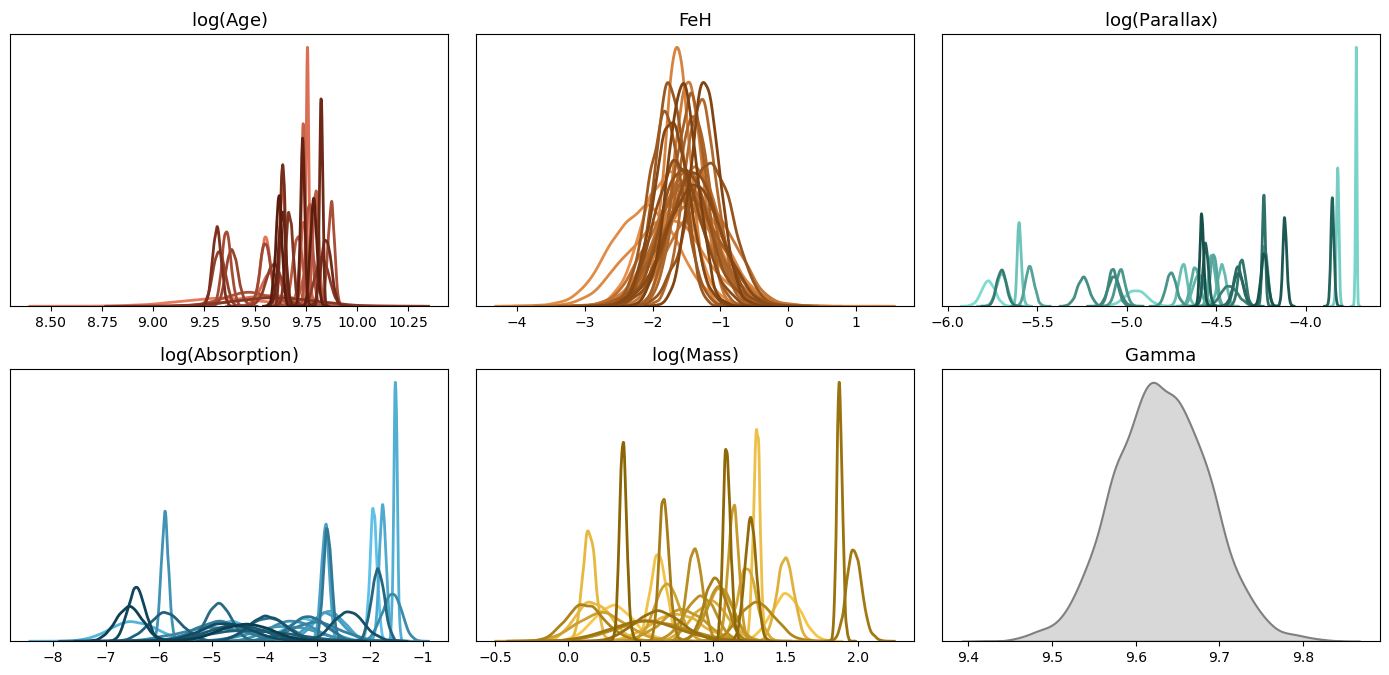

In [7]:
def make_colors(light_hex, dark_hex, n):
    cmap = LinearSegmentedColormap.from_list("grad", [light_hex, dark_hex])
    return [cmap(i/(n-1)) for i in range(n)] if n > 1 else [dark_hex]

def plot_stage2(model, selected_ids, title = '', num_samples = 2000):

    color_bounds = {
        "logAge": ("#E9795D", "#5A1B0C"),
        "FeH": ("#E8914A", "#7E4210"),
        "parallax": ("#7FDCD1", "#165049"),
        "absorption": ("#5DC1E9", "#0B3D51"),
        "mass": ("#F9C94D", "#8B6404")
    }
    subplot_titles = {
        "logAge": r"$\log(\mathrm{Age})$",
        "FeH": "FeH",
        "parallax": r"$\log(\mathrm{Parallax})$",
        "absorption": r"$\log(\mathrm{Absorption})$",
        "mass": r"$\log(\mathrm{Mass})$",
        "gamma": "Gamma"
    }

    torch.manual_seed(0)
    model.eval()
    with torch.no_grad():
        z, _ = model.sample(num_samples)
    z = z.detach().cpu().numpy()

    columns = []
    for id_ in selected_ids:
        columns += [f"logAge_{id_}", f"FeH_{id_}", f"parallax_{id_}", f"absorption_{id_}", f"mass_{id_}"]
    columns += ["gamma"]

    df = pd.DataFrame(z, columns=columns)
    n_age = len(selected_ids)

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.ravel()

    variables = cols + ["gamma"]
    for idx, var in enumerate(variables):
        ax = axes[idx]

        if var == "gamma":
            sns.kdeplot(df["gamma"], fill=True, color="gray", ax=ax,  alpha=0.3, linewidth=1.5)
            ax.set_title(subplot_titles["gamma"], fontsize=13)
        else:
            light, dark = color_bounds[var]
            colors = make_colors(light, dark, n_age)
            for i, id_ in enumerate(selected_ids):
                colname = f"{var}_{id_}"
                sns.kdeplot(df[colname], color=colors[i], ax=ax, linewidth=2, label=f"ID {id_}")
            ax.set_title(subplot_titles[var], fontsize=13)
        
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_yticks([])
    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_stage2(model = nfm, selected_ids= selected_ids ,num_samples=5000)
